# Librerías

In [1]:
import scienceplots
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ccdproc

from astropy.io import fits
from astropy import units as u
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
from astropy.nddata import CCDData, Cutout2D
from astropy.table import Table
from astropy.stats import sigma_clipped_stats, SigmaClip
from astropy.coordinates import SkyCoord
from astropy.visualization import simple_norm
from astropy.visualization import (MinMaxInterval, SqrtStretch, LogStretch, LinearStretch, ImageNormalize, ZScaleInterval)
from matplotlib.colors import LogNorm

from os import listdir  
from os.path import join
from ccdproc import subtract_bias ,subtract_dark, flat_correct, combine
from photutils.detection import DAOStarFinder
from photutils.aperture import CircularAperture, CircularAnnulus, aperture_photometry, ApertureStats
from photutils.background import Background2D, MedianBackground
from astroquery.astrometry_net import AstrometryNet

plt.style.use('science')
%matplotlib inline

import warnings
from astropy.utils.exceptions import AstropyWarning
from astropy import log
warnings.simplefilter('ignore', category=AstropyWarning)
log.setLevel('ERROR')

# Funciones

In [2]:
def calcular_fwhm(filename):
    data = np.loadtxt(filename)
    x = data[:, 0]
    y = data[:, 1]

    fondo = np.median(np.concatenate([y[:5], y[-5:]]))
    max_val = np.max(y)
    half_max = fondo + (max_val - fondo) / 2
    indices_arriba = np.where(y >= half_max)[0]
    n_inicio = indices_arriba[0]
    n_fin = indices_arriba[-1]

    x1 = np.interp(half_max, [y[n_inicio - 1], y[n_inicio]], [x[n_inicio - 1], x[n_inicio]])
    x2 = np.interp(half_max, [y[n_fin], y[n_fin + 1]], [x[n_fin], x[n_fin + 1]])
    fwhm = x2 - x1
    
    print(float(fwhm))
    return float(fwhm)

def emparejar_con_detecciones(coords, sources, tol=10):
    x_det = np.array(sources["xcentroid"])
    y_det = np.array(sources["ycentroid"])

    coords_refinadas = []
    for x, y in coords:
        mask = (np.abs(x_det - x) <= tol) & (np.abs(y_det - y) <= tol)
        idx_candidatas = np.where(mask)[0]

        if len(idx_candidatas) == 0:
            print(f"Sin detección cerca de ({x:.1f}, {y:.1f}) dentro de ±{tol}px — se usa la coordenada original")
            coords_refinadas.append((x, y))
            continue

        dist = np.sqrt((x_det[idx_candidatas] - x) ** 2 + (y_det[idx_candidatas] - y) ** 2)
        idx_mejor = idx_candidatas[np.argmin(dist)]

        if len(idx_candidatas) > 1:
            print(f"Nota: {len(idx_candidatas)} detecciones cerca de ({x:.1f}, {y:.1f}) — "
                  f"posible saturación/blending, se usa la más cercana")

        coords_refinadas.append((float(x_det[idx_mejor]), float(y_det[idx_mejor])))
        
    return coords_refinadas

def curva_crecimiento(data, positions, radios, r_in_cielo, r_out_cielo,
                       fwhm_ref, tolerancia, titulo, archivo_salida):
    n_estrellas = len(positions)
    magnitudes = np.zeros((n_estrellas, len(radios)))
    anillo = CircularAnnulus(positions, r_in=r_in_cielo, r_out=r_out_cielo)

    for j, r in enumerate(radios):
        apertura = CircularAperture(positions, r=r)
        tabla = aperture_photometry(data, [apertura, anillo])
        fondo_por_pixel = tabla["aperture_sum_1"] / anillo.area
        flujo_neto = tabla["aperture_sum_0"] - fondo_por_pixel * apertura.area
        with np.errstate(invalid="ignore"):
            magnitudes[:, j] = -2.5 * np.log10(flujo_neto)

    diff_mag = np.diff(magnitudes, axis=1)
    radios_medios = (radios[1:] + radios[:-1]) / 2

    fig, ax = plt.subplots(figsize=(8, 6))
    for i in range(n_estrellas):
        x, y = positions[i]
        ax.plot(radios_medios, diff_mag[i], marker="o", markersize=4, label=f"Estrella {i+1}")

    radio_por_estrella = []
    for i in range(n_estrellas):
        idx_estable = np.where(np.abs(diff_mag[i]) < tolerancia)[0]
        if len(idx_estable) > 0:
            radio_por_estrella.append(radios_medios[idx_estable[0]])
    radio_optimo = max(radio_por_estrella)

    ax.axhline(0, color="black", lw=1)
    ax.axvline(fwhm_ref, color="green", ls="--", alpha=0.6, label="FWHM")
    ax.axvline(radio_optimo, color="red", ls="--", lw=1.5, label=f"Radio óptimo = {radio_optimo:.2f} px")
    ax.set_xlabel("Radio de apertura [px]", fontsize=16)
    ax.set_ylabel(r"mag($R_i$) $-$ mag($R_{i-1}$) [mag]", fontsize=16)
    ax.set_title(titulo, fontsize=16)
    ax.legend(fontsize=14)
    ax.grid()
    ax.tick_params(axis='both', labelsize=12)
    plt.tight_layout()
    plt.savefig(archivo_salida)
    plt.show()

    print(f"Radio óptimo ({titulo}): {radio_optimo:.2f} px")
    return radio_optimo, magnitudes

def convertir_coords_wcs(coords, wcs_origen, wcs_destino):
    x, y = np.array(coords).T
    sky = wcs_origen.pixel_to_world(x, y)
    x_dest, y_dest = wcs_destino.world_to_pixel(sky)
    return list(zip(x_dest, y_dest))

# Estimaciones FWHM

In [ ]:
sufijos = ['_sg', '_cg', '_sr', '_cr']
fwhm_values = [] # 0 = sg, 1 = cg, 2 = sr, 3 = cr

for sufijo in sufijos:
    archivos = []
    for i in range(1,8):
        palabra = ['data/estrella', str(i), sufijo]
        name = ''.join(palabra)
        archivos.append(name)
    fwhm_valor = [calcular_fwhm(archivo) for archivo in archivos]
    fwhm = np.mean(fwhm_valor)
    fwhm_values.append(fwhm)

# Único codigo que no hizo Claude xD

print(f'hola {fwhm_values[3]:.2f}')

7.67640559166853
7.565011499952632
7.550840664381408
7.775567391011595
8.08689269348892
8.15959347906636
7.466173400498231
7.119920150171652
8.434194817707905
6.266099507552443
7.038459705613331
7.275769350711624
6.6972513305195776
6.592397298524762
6.443955327964087
5.620697436657839
6.448849661935018
6.260401792895131
6.162111675380974
5.9940031118504
6.004205457664792
6.23597527296047
6.806972278286615
6.356743398024964
5.883446576952295
6.352614125591334
6.745018152505352
6.846408246241271
hola 6.46


# Imagen single banda g

In [4]:
single = CCDData.read("fits/image_visit_image-g.fits", hdu=1, unit="nJy")
mean, median, std = sigma_clipped_stats(single, sigma=3.0)

daofind = DAOStarFinder(fwhm=fwhm_values[0], threshold=7.0 * std)
sources_sg = daofind(single - median)

print(sources_sg)

 id      x_centroid     ...     mag          daofind_mag      
---- ------------------ ... ----------- ----------------------
   1 245.83177108024222 ... -12.0303955     -3.965601729426691
   2 1616.9146233660608 ...   -8.853062    -0.1782130822483716
   3 1551.2208349273087 ...   -9.569888     -1.359273140048595
   4 2063.6117628701236 ...   -8.387685 -0.0011871768704459745
   5  2357.519570613709 ...   -9.320646    -0.8203141671377191
   6  4052.833500497899 ...   -11.84514    -3.0250583202162415
   7 1958.4763738143956 ...  -12.741967    -3.9531776394851366
   8 2553.9272760525846 ...   -8.946153    -0.1361554142699845
   9 2452.8590381254835 ...  -13.408421     -4.618542401053953
  10  451.8469927597643 ...   -9.226854   -0.24548009673263854
 ...                ... ...         ...                    ...
3495  2963.399160912225 ...   -9.008113   -0.16822897211660512
3496 2770.3991473238225 ...   -9.513994     -0.848438846550421
3497 2088.7515046477592 ...   -9.580305    -0.790282269

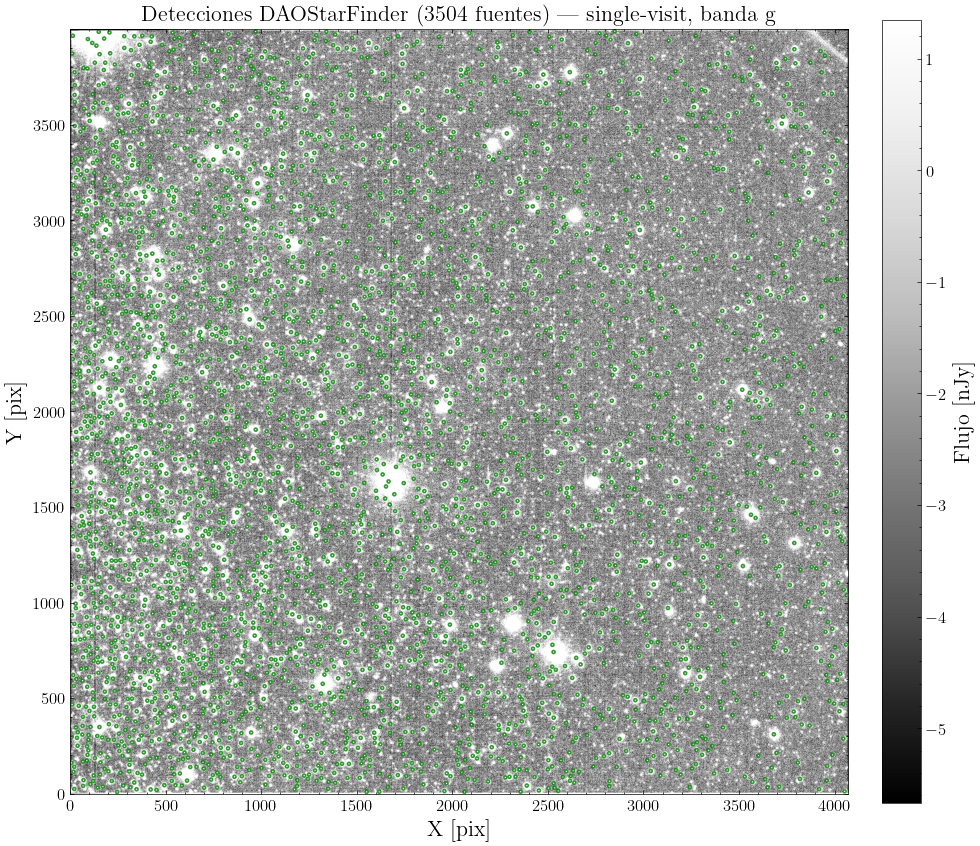

In [5]:
positions_single = np.transpose((sources_sg["xcentroid"], sources_sg["ycentroid"]))
apertures_single = CircularAperture(positions_single, r=fwhm_values[0])

norm = ImageNormalize(
    single.data, interval=ZScaleInterval(), stretch=LinearStretch()
)

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(single.data, cmap="Greys_r", origin="lower", norm=norm)
apertures_single.plot(color="green", lw=1.2, alpha=0.8, ax=ax)

ax.set_title(f"Detecciones DAOStarFinder ({len(sources_sg)} fuentes) — single-visit, banda g", fontsize=16)
ax.set_xlabel("X [pix]", fontsize=16)
ax.set_ylabel("Y [pix]", fontsize=16)
ax.tick_params(axis='both', labelsize=12)
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=12)
cbar.set_label(f"Flujo [{single.unit}]", size=16)
plt.tight_layout()
plt.savefig('2 - detecciones single (g).pdf')
plt.show()

In [6]:
estrellas_candidatas = [
    (2836, 2055),
    (3479, 2814),
    (2918, 3927),
    (2286, 3457),
    (3909, 1676)
]

estrellas_refinadas = emparejar_con_detecciones(estrellas_candidatas, sources_sg, tol=10)

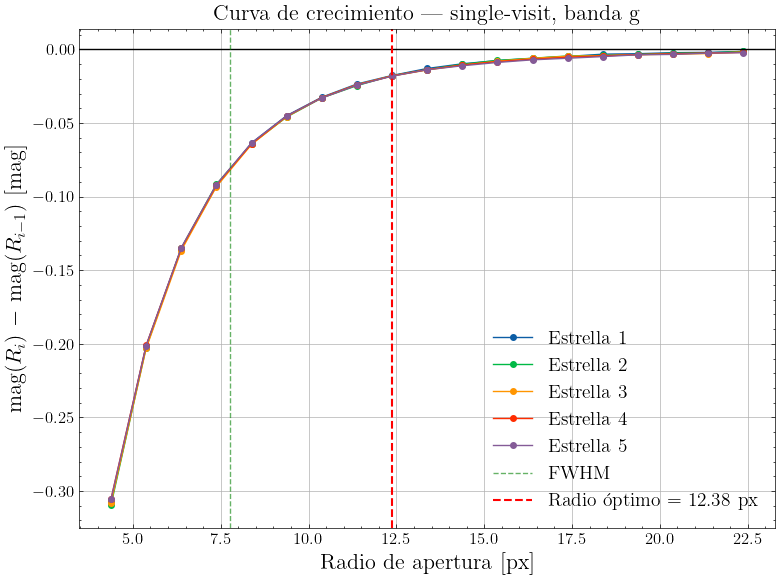

Radio óptimo (Curva de crecimiento — single-visit, banda g): 12.38 px


In [7]:
radios_sg = np.arange(0.5 * fwhm_values[0], 3* fwhm_values[0], 1)
r_in_cielo_sg, r_out_cielo_sg = 3.5 * fwhm_values[0], 5.5 * fwhm_values[0] 
tolerancia = 0.02  

radio_optimo_sg, magnitudes_sg = curva_crecimiento(
    single.data, estrellas_refinadas, radios_sg, r_in_cielo_sg, r_out_cielo_sg,
    fwhm_values[0], tolerancia,
    titulo="Curva de crecimiento — single-visit, banda g",
    archivo_salida="4 - curva de crecimiento single.pdf"
)

# Imagen coadd banda g

In [8]:
coadd = CCDData.read("fits/image_deep_coadd-g.fits", hdu=1, unit="nJy")  # ajusta el nombre de archivo al tuyo
mean_c, median_c, std_c = sigma_clipped_stats(coadd, sigma=3.0)

daofind_c = DAOStarFinder(fwhm=fwhm_values[1], threshold=7.0 * std_c)
sources_cg = daofind_c(coadd - median_c)

print(sources_cg)

 id      x_centroid         y_centroid     ...    mag          daofind_mag     
---- ------------------ ------------------ ... ---------- ---------------------
   1 166.33895585039878 1.4340363336692898 ... -10.172838    -2.951121653936487
   2  1034.450620897635 1.2730314607952695 ... -7.0912848 -0.027634863792041976
   3 1288.4715900835545 1.0645045445570096 ...  -8.739024   -1.6280215953401025
   4 2672.2751655782326  1.226706237817863 ...  -8.412153   -1.1449940992399648
   5 1492.9679334108837 1.9374742703276524 ... -7.9534903   -0.5515554660653498
   6  2387.645074942154 1.9053294242785321 ...  -7.602803   -0.5054716419919238
   7  607.2980161957491  3.245370784681512 ... -10.244445   -2.5861439517629847
   8 1732.0963112283061 4.4217562536117105 ...  -9.389933   -1.5431558099773373
   9 3173.3957672804345  4.103214263422202 ...  -9.360693    -1.562158307365869
  10 1610.7899253301334 4.8150591933037346 ...  -8.755161   -1.0411407691602905
 ...                ...                .

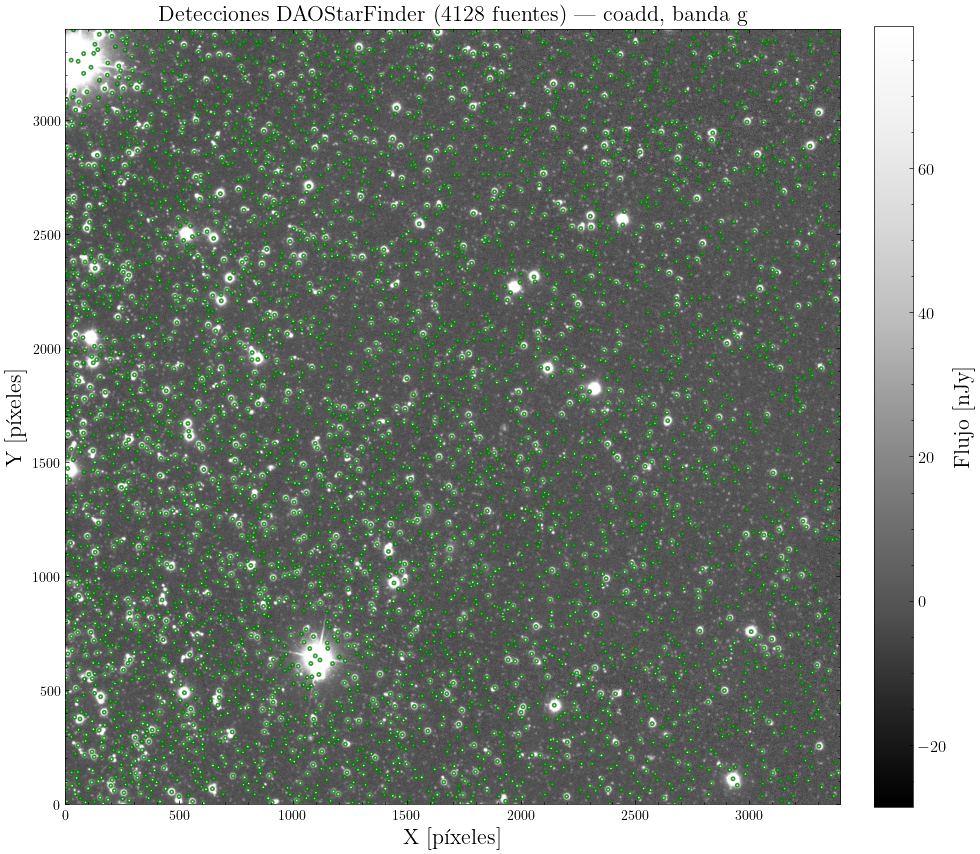

In [9]:
positions_coadd = np.transpose((sources_cg["xcentroid"], sources_cg["ycentroid"]))
apertures_coadd = CircularAperture(positions_coadd, r=fwhm_values[1])

norm_c = ImageNormalize(
    coadd.data, interval=ZScaleInterval(), stretch=LinearStretch()
)

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(coadd.data, cmap="Greys_r", origin="lower", norm=norm_c)
apertures_coadd.plot(color="green", lw=1.2, alpha=0.8, ax=ax)

ax.set_title(f"Detecciones DAOStarFinder ({len(sources_cg)} fuentes) — coadd, banda g", fontsize=16)
ax.set_xlabel("X [píxeles]", fontsize=16)
ax.set_ylabel("Y [píxeles]", fontsize=16)
cbar = plt.colorbar(im, ax=ax, label=f"Flujo [{coadd.unit}]", fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=12)
cbar.set_label(f"Flujo [{single.unit}]", size=16)
plt.tight_layout()
plt.savefig('2 - detecciones coadd (g).pdf')
plt.show()

In [10]:
wcs_sg = single.wcs
wcs_cg = coadd.wcs

estrellas_candidatas_cg = convertir_coords_wcs(estrellas_candidatas, wcs_sg, wcs_cg)
estrellas_refinadas_cg = emparejar_con_detecciones(estrellas_candidatas_cg, sources_cg, tol=10)

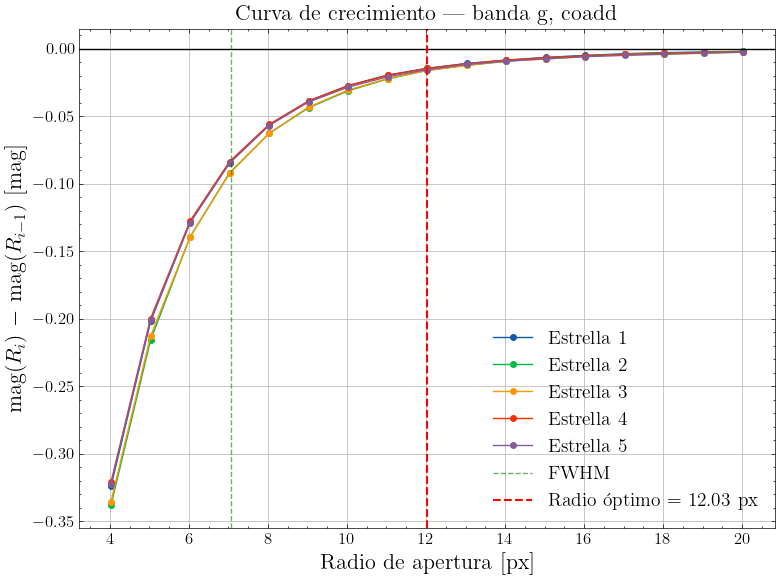

Radio óptimo (Curva de crecimiento — banda g, coadd): 12.03 px


In [11]:
radios_cg = np.arange(0.5 * fwhm_values[1], 3 * fwhm_values[1], 1)
r_in_cielo_cg, r_out_cielo_cg = 3.5 * fwhm_values[1], 5.5 * fwhm_values[1]

radio_optimo_cg, magnitudes_cg = curva_crecimiento(
    coadd.data, estrellas_refinadas_cg, radios_cg, r_in_cielo_cg, r_out_cielo_cg,
    fwhm_values[1], tolerancia,
    titulo="Curva de crecimiento — banda g, coadd",
    archivo_salida="4 - curva de crecimiento coadd.pdf"
)

# Fotometrías g

-> Single G

In [12]:
idx_radio_optimo_sg = np.argmin(np.abs(radios_sg - radio_optimo_sg))

correccion_apertura_sg = np.mean(magnitudes_sg[:, -1] - magnitudes_sg[:, idx_radio_optimo_sg])
print(f"Corrección de apertura: {correccion_apertura_sg:.4f} mag")

Corrección de apertura: -0.0763 mag


In [13]:
positions_todas_sg = np.transpose((sources_sg["xcentroid"], sources_sg["ycentroid"]))
apertura_optima_sg = CircularAperture(positions_todas_sg, r=radio_optimo_sg)
anillo_cielo_sg = CircularAnnulus(positions_todas_sg, r_in=r_in_cielo_sg, r_out=r_out_cielo_sg)

varianza_map_sg = CCDData.read("fits/image_visit_image-g.fits", hdu=3, unit="nJy**2").data
sigma_map_sg = np.sqrt(varianza_map_sg)

tabla_fot_sg = aperture_photometry(single.data, [apertura_optima_sg, anillo_cielo_sg], error=sigma_map_sg)
sigclip_sg = SigmaClip(sigma=3.0, maxiters=10)
fondo_stats_sg = ApertureStats(single.data, anillo_cielo_sg, sigma_clip=sigclip_sg)
fondo_por_pixel_sg = fondo_stats_sg.median
sigma_cielo_sg = fondo_stats_sg.std

flujo_neto_sg = tabla_fot_sg["aperture_sum_0"] - fondo_por_pixel_sg * apertura_optima_sg.area
flujo_total_sg = flujo_neto_sg * 10**(-correccion_apertura_sg / 2.5)
magnitud_sg = -2.5 * np.log10(flujo_total_sg)

# Errores
n_pix_ap_sg = apertura_optima_sg.area
n_pix_cielo_sg = anillo_cielo_sg.area

error_aperture_sg = tabla_fot_sg["aperture_sum_err_0"]  
error_fondo_prop_sg = n_pix_ap_sg * (sigma_cielo_sg / np.sqrt(n_pix_cielo_sg))  

error_flujo_sg = np.sqrt(error_aperture_sg**2 + error_fondo_prop_sg**2)
error_mag_sg = (2.5 / np.log(10)) * (error_flujo_sg / flujo_neto_sg)

C:\Users\nicol\AppData\Local\Temp\ipykernel_15540\939583178.py:16: RuntimeWarning: invalid value encountered in log10
  magnitud_sg = -2.5 * np.log10(flujo_total_sg)


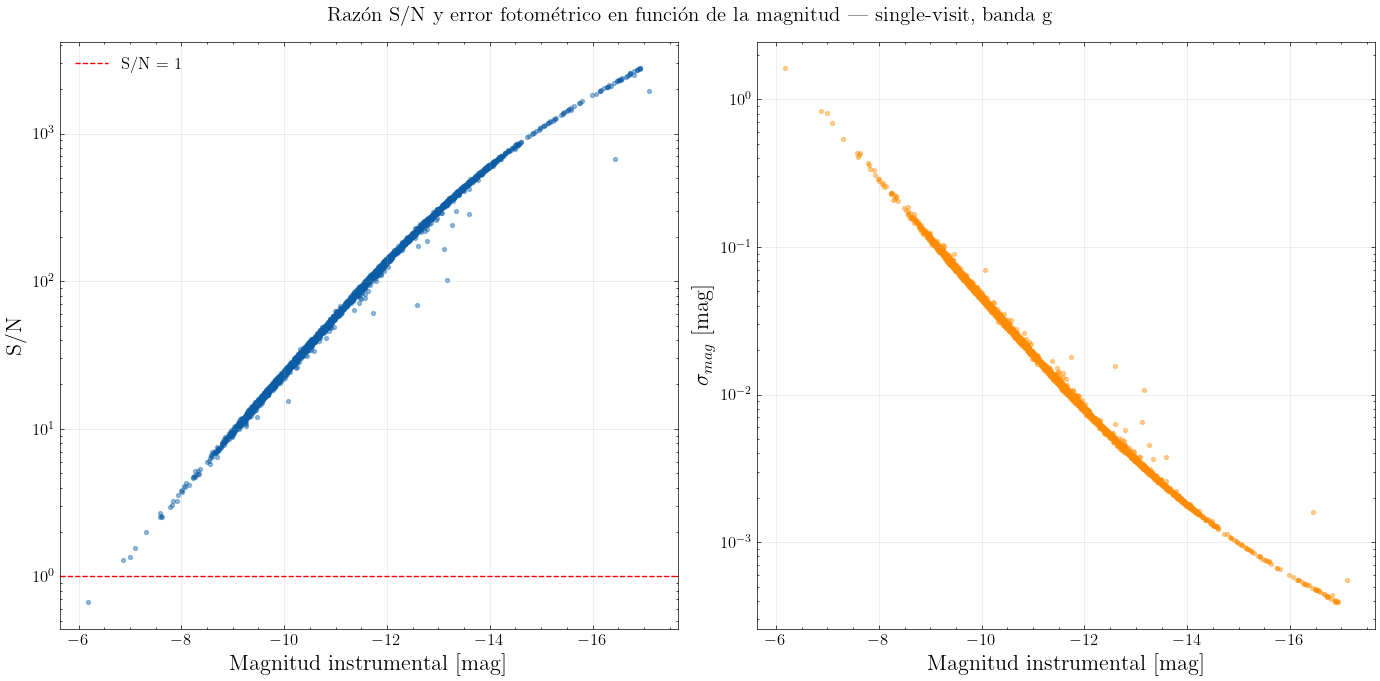

In [14]:
snr_sg = flujo_neto_sg / error_flujo_sg

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].scatter(magnitud_sg, snr_sg, s=8, alpha=0.4)
axes[0].set_yscale("log")
axes[0].axhline(1, color="red", ls="--", lw=1, label="S/N = 1")
axes[0].set_xlabel("Magnitud instrumental [mag]", fontsize=16)
axes[0].set_ylabel("S/N", fontsize=16)
axes[0].invert_xaxis()
axes[0].legend(fontsize=12)
axes[0].grid(alpha=0.3)
axes[0].tick_params(axis='both', labelsize=12)

axes[1].scatter(magnitud_sg, error_mag_sg, s=8, alpha=0.4, color="darkorange")
axes[1].set_yscale("log")
axes[1].set_xlabel("Magnitud instrumental [mag]", fontsize=16)
axes[1].set_ylabel(r"$\sigma_{mag}$ [mag]", fontsize=16)
axes[1].invert_xaxis()
axes[1].grid(alpha=0.3)
axes[1].tick_params(axis='both', labelsize=12)

fig.suptitle("Razón S/N y error fotométrico en función de la magnitud — single-visit, banda g", fontsize=15)
plt.tight_layout()
plt.savefig("5 - SN y error vs magnitud (sg).pdf")
plt.show()

-> Coadd g

In [15]:
idx_radio_optimo_cg = np.argmin(np.abs(radios_cg - radio_optimo_cg))

correccion_apertura_cg = np.mean(magnitudes_cg[:, -1] - magnitudes_cg[:, idx_radio_optimo_cg])
print(f"Corrección de apertura: {correccion_apertura_cg:.4f} mag")

Corrección de apertura: -0.0613 mag


In [16]:
positions_todas_cg = np.transpose((sources_cg["xcentroid"], sources_cg["ycentroid"]))
apertura_optima_cg = CircularAperture(positions_todas_cg, r=radio_optimo_cg)
anillo_cielo_cg = CircularAnnulus(positions_todas_cg, r_in=r_in_cielo_cg, r_out=r_out_cielo_cg)

varianza_map_cg = CCDData.read("fits/image_deep_coadd-g.fits", hdu=3, unit="nJy**2").data
sigma_map_cg = np.sqrt(varianza_map_cg)

tabla_fot_cg = aperture_photometry(coadd.data, [apertura_optima_cg, anillo_cielo_cg], error=sigma_map_cg)
sigclip_cg = SigmaClip(sigma=3.0, maxiters=10)
fondo_stats_cg = ApertureStats(coadd.data, anillo_cielo_cg, sigma_clip=sigclip_cg)
fondo_por_pixel_cg = fondo_stats_cg.median
sigma_cielo_cg = fondo_stats_cg.std

flujo_neto_cg = tabla_fot_cg["aperture_sum_0"] - fondo_por_pixel_cg * apertura_optima_cg.area
flujo_total_cg = flujo_neto_cg * 10**(-correccion_apertura_cg / 2.5)
magnitud_cg = -2.5 * np.log10(flujo_total_cg)

# Errores
n_pix_ap_cg = apertura_optima_cg.area
n_pix_cielo_cg = anillo_cielo_cg.area

error_aperture_cg = tabla_fot_cg["aperture_sum_err_0"]  
error_fondo_prop_cg = n_pix_ap_cg * (sigma_cielo_cg / np.sqrt(n_pix_cielo_cg)) 

error_flujo_cg = np.sqrt(error_aperture_cg**2 + error_fondo_prop_cg**2)
error_mag_cg = (2.5 / np.log(10)) * (error_flujo_cg / flujo_neto_cg)

C:\Users\nicol\AppData\Local\Temp\ipykernel_15540\1182979876.py:16: RuntimeWarning: invalid value encountered in log10
  magnitud_cg = -2.5 * np.log10(flujo_total_cg)


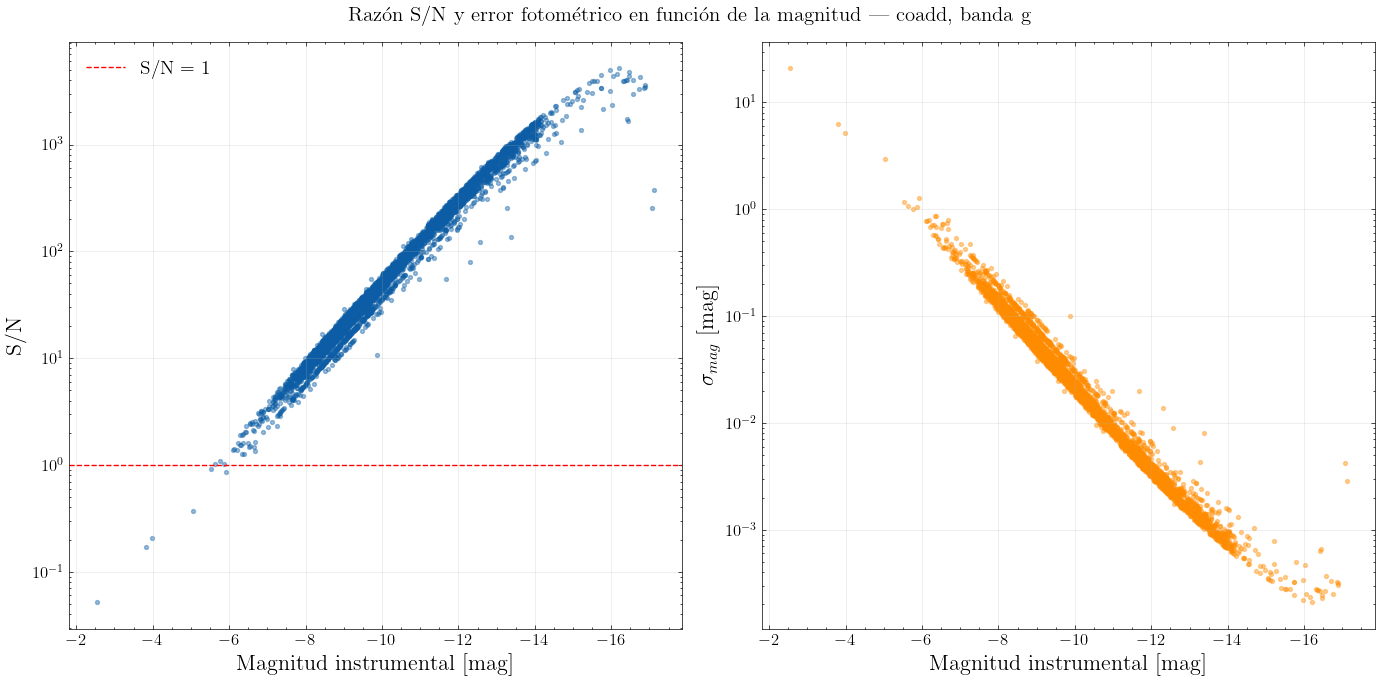

In [17]:
snr_cg = flujo_neto_cg / error_flujo_cg

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].scatter(magnitud_cg, snr_cg, s=8, alpha=0.4)
axes[0].set_yscale("log")
axes[0].axhline(1, color="red", ls="--", lw=1, label="S/N = 1")
axes[0].set_xlabel("Magnitud instrumental [mag]", fontsize=16)
axes[0].set_ylabel("S/N", fontsize=16)
axes[0].invert_xaxis()
axes[0].legend(fontsize=14)
axes[0].grid(alpha=0.3)
axes[0].tick_params(axis='both', labelsize=12)

axes[1].scatter(magnitud_cg, error_mag_cg, s=8, alpha=0.4, color="darkorange")
axes[1].set_yscale("log")
axes[1].set_xlabel("Magnitud instrumental [mag]", fontsize=16)
axes[1].set_ylabel(r"$\sigma_{mag}$ [mag]", fontsize=16)
axes[1].invert_xaxis()
axes[1].grid(alpha=0.3)
axes[1].tick_params(axis='both', labelsize=12)

plt.suptitle("Razón S/N y error fotométrico en función de la magnitud — coadd, banda g", fontsize=15)
plt.tight_layout()
plt.savefig("5 - SN y error vs magnitud (cg).pdf")
plt.show()

# Comparación

In [18]:
sky_sg = wcs_sg.pixel_to_world(sources_sg["xcentroid"], sources_sg["ycentroid"])
sky_cg = wcs_cg.pixel_to_world(sources_cg["xcentroid"], sources_cg["ycentroid"])

pixel_scale_sg = (proj_plane_pixel_scales(wcs_sg) * u.deg).to(u.arcsec)[0]
print(f"Escala de píxel (sg): {pixel_scale_sg:.3f}")

idx_match, sep2d, _ = sky_sg.match_to_catalog_sky(sky_cg)

tol_match = 0.5 * u.arcsec
mask_match = sep2d < tol_match

idx_sg_match = np.where(mask_match)[0]
idx_cg_match = idx_match[mask_match]

print(f"Estrellas en común encontradas: {len(idx_sg_match)}")

Escala de píxel (sg): 0.200 arcsec
Estrellas en común encontradas: 1957


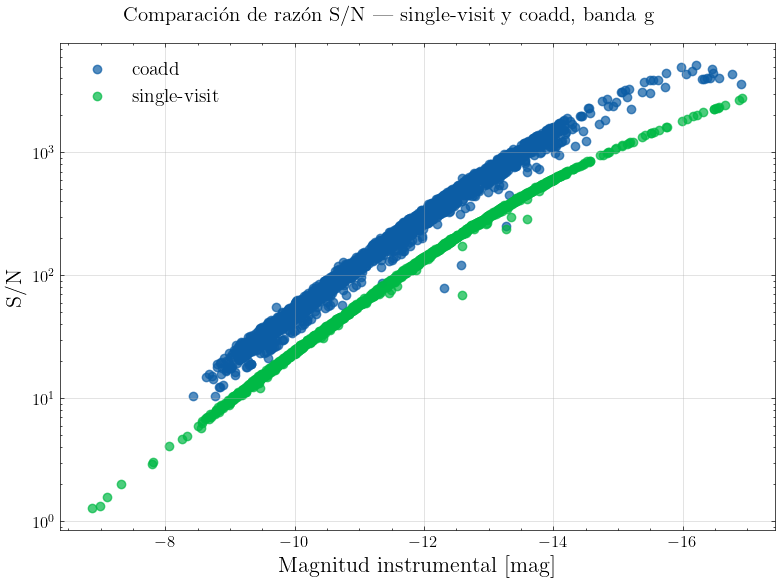

In [19]:
# Comparación de SNRs
mag_sg_m = magnitud_sg[idx_sg_match]
mag_cg_m = magnitud_cg[idx_cg_match]
err_sg_m = error_mag_sg[idx_sg_match]
err_cg_m = error_mag_cg[idx_cg_match]
snr_sg_m = snr_sg[idx_sg_match]
snr_cg_m = snr_cg[idx_cg_match]

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(mag_cg_m, snr_cg_m, label="coadd", alpha=0.7)
ax.scatter(mag_sg_m, snr_sg_m, label="single-visit", alpha=0.7)
ax.set_yscale("log")
ax.invert_xaxis()
ax.set_xlabel("Magnitud instrumental [mag]", fontsize=16)
ax.set_ylabel("S/N", fontsize=16)
ax.legend(fontsize=14)
ax.tick_params(axis='both', labelsize=12)
ax.grid(alpha=0.5)

fig.suptitle(f"Comparación de razón S/N — single-visit y coadd, banda g", fontsize=15)
plt.tight_layout()
plt.savefig("6 - comparacion errores SN sg vs cg.pdf")
plt.show()

In [20]:
# Comparación de errores
tabla_comparacion = pd.DataFrame({
    "mag_sg": mag_sg_m,
    "err_sg": err_sg_m,
    "mag_cg": mag_cg_m,
    "err_cg": err_cg_m,
})

tabla_comparacion = tabla_comparacion.sort_values("mag_sg").reset_index(drop=True)

n_muestra = 15
idx_muestra = np.linspace(0, len(tabla_comparacion) - 1, n_muestra).astype(int)
muestra = tabla_comparacion.iloc[idx_muestra].reset_index(drop=True)

print(muestra.round(3))

mejora_snr = np.median(snr_cg_m / snr_sg_m)
mejora_error = np.median(err_sg_m / err_cg_m)
print(f"Mejora mediana en S/N (coadd/single): {mejora_snr:.2f}x")
print(f"Reducción mediana en error (single/coadd): {mejora_error:.2f}x")

    mag_sg  err_sg  mag_cg  err_cg
0  -16.924   0.000 -16.896   0.000
1  -13.811   0.002 -13.790   0.001
2  -13.272   0.003 -13.264   0.002
3  -12.800   0.004 -12.745   0.002
4  -12.428   0.006 -12.425   0.002
5  -12.055   0.007 -12.046   0.004
6  -11.726   0.010 -11.695   0.004
7  -11.443   0.013 -11.414   0.005
8  -11.018   0.019 -10.986   0.008
9  -10.653   0.025 -10.593   0.011
10 -10.341   0.034  -9.707   0.020
11 -10.003   0.047 -10.140   0.016
12  -9.641   0.063  -9.638   0.028
13  -9.325   0.081  -9.327   0.057
14  -6.871   0.838  -8.683   0.069
Mejora mediana en S/N (coadd/single): 2.27x
Reducción mediana en error (single/coadd): 2.27x


# Fotometrías r

In [21]:
# Estimación radio óptimo 
factor_g = radio_optimo_sg / fwhm_values[0]
radio_optimo_sr = factor_g * fwhm_values[2]
r_in_cielo_sr, r_out_cielo_sr = 3.5 * fwhm_values[2], 5.5 * fwhm_values[2]

factor_cg = radio_optimo_cg / fwhm_values[1]
radio_optimo_cr = factor_cg * fwhm_values[3]
r_in_cielo_cr, r_out_cielo_cr = 3.5 * fwhm_values[3], 5.5 * fwhm_values[3]

# aproximación razonable: si el radio óptimo escala con el FWHM,
# la fracción de luz capturada (y por tanto la corrección de apertura) debería ser similar entre bandas
correccion_apertura_sr = correccion_apertura_sg
correccion_apertura_cr = correccion_apertura_cg

print(f"Radio óptimo estimado (sr, escalado por FWHM): {radio_optimo_sr:.2f} px")
print(f"Radio óptimo estimado (cr, escalado por FWHM): {radio_optimo_cr:.2f} px")

Radio óptimo estimado (sr, escalado por FWHM): 9.79 px
Radio óptimo estimado (cr, escalado por FWHM): 11.01 px


-> Single r

In [22]:
single_r = CCDData.read("fits/image_visit_image-r.fits", hdu=1, unit="nJy")
wcs_sr = single_r.wcs
radios_sr = np.arange(0.5 * fwhm_values[2], 3 * fwhm_values[2], 1)
r_in_cielo_sr, r_out_cielo_sr = 3.5 * fwhm_values[2], 5.5 * fwhm_values[2]

positions_sg_en_sr = np.array(convertir_coords_wcs(
    list(zip(sources_sg["xcentroid"], sources_sg["ycentroid"])), wcs_sg, wcs_sr
))

apertura_optima_sr = CircularAperture(positions_sg_en_sr, r=radio_optimo_sr)
anillo_cielo_sr = CircularAnnulus(positions_sg_en_sr, r_in=r_in_cielo_sr, r_out=r_out_cielo_sr)

varianza_map_sr = CCDData.read("fits/image_visit_image-r.fits", hdu=3, unit="nJy**2").data
sigma_map_sr = np.sqrt(varianza_map_sr)

tabla_fot_sr = aperture_photometry(single_r.data, [apertura_optima_sr, anillo_cielo_sr], error=sigma_map_sr)
sigclip_sr = SigmaClip(sigma=3.0, maxiters=10)
fondo_stats_sr = ApertureStats(single_r.data, anillo_cielo_sr, sigma_clip=sigclip_sr)
fondo_por_pixel_sr = fondo_stats_sr.median
sigma_cielo_sr = fondo_stats_sr.std

flujo_neto_sr = tabla_fot_sr["aperture_sum_0"] - fondo_por_pixel_sr * apertura_optima_sr.area
flujo_total_sr = flujo_neto_sr * 10**(-correccion_apertura_sr / 2.5)
magnitud_sr = -2.5 * np.log10(flujo_total_sr)

n_pix_ap_sr = apertura_optima_sr.area
n_pix_cielo_sr = anillo_cielo_sr.area
error_aperture_sr = tabla_fot_sr["aperture_sum_err_0"]
error_fondo_prop_sr = n_pix_ap_sr * (sigma_cielo_sr / np.sqrt(n_pix_cielo_sr))
error_flujo_sr = np.sqrt(error_aperture_sr**2 + error_fondo_prop_sr**2)
error_mag_sr = (2.5 / np.log(10)) * (error_flujo_sr / flujo_neto_sr)

C:\Users\nicol\AppData\Local\Temp\ipykernel_15540\3071160054.py:24: RuntimeWarning: invalid value encountered in log10
  magnitud_sr = -2.5 * np.log10(flujo_total_sr)


-> Coadd_r

In [23]:
coadd_r = CCDData.read("fits/image_deep_coadd-r.fits", hdu=1, unit="nJy")  # ajusta si el nombre difiere
wcs_cr = coadd_r.wcs
radios_cr = np.arange(0.5 * fwhm_values[3], 3 * fwhm_values[3], 1)
r_in_cielo_cr, r_out_cielo_cr = 3.5 * fwhm_values[3], 5.5 * fwhm_values[3]

positions_cg_en_cr = np.array(convertir_coords_wcs(
    list(zip(sources_cg["xcentroid"], sources_cg["ycentroid"])), wcs_cg, wcs_cr
))

apertura_optima_cr = CircularAperture(positions_cg_en_cr, r=radio_optimo_cr)
anillo_cielo_cr = CircularAnnulus(positions_cg_en_cr, r_in=r_in_cielo_cr, r_out=r_out_cielo_cr)

varianza_map_cr = CCDData.read("fits/image_deep_coadd-r.fits", hdu=3, unit="nJy**2").data
sigma_map_cr = np.sqrt(varianza_map_cr)

tabla_fot_cr = aperture_photometry(coadd_r.data, [apertura_optima_cr, anillo_cielo_cr], error=sigma_map_cr)
sigclip_cr = SigmaClip(sigma=3.0, maxiters=10)
fondo_stats_cr = ApertureStats(coadd_r.data, anillo_cielo_cr, sigma_clip=sigclip_cr)
fondo_por_pixel_cr = fondo_stats_cr.median
sigma_cielo_cr = fondo_stats_cr.std

flujo_neto_cr = tabla_fot_cr["aperture_sum_0"] - fondo_por_pixel_cr * apertura_optima_cr.area
flujo_total_cr = flujo_neto_cr * 10**(-correccion_apertura_cr / 2.5)
magnitud_cr = -2.5 * np.log10(flujo_total_cr)

n_pix_ap_cr = apertura_optima_cr.area
n_pix_cielo_cr = anillo_cielo_cr.area
error_aperture_cr = tabla_fot_cr["aperture_sum_err_0"]
error_fondo_prop_cr = n_pix_ap_cr * (sigma_cielo_cr / np.sqrt(n_pix_cielo_cr))
error_flujo_cr = np.sqrt(error_aperture_cr**2 + error_fondo_prop_cr**2)
error_mag_cr = (2.5 / np.log(10)) * (error_flujo_cr / flujo_neto_cr)

C:\Users\nicol\AppData\Local\Temp\ipykernel_15540\1187578377.py:24: RuntimeWarning: invalid value encountered in log10
  magnitud_cr = -2.5 * np.log10(flujo_total_cr)


-> Chequeo radio óptimo escalado

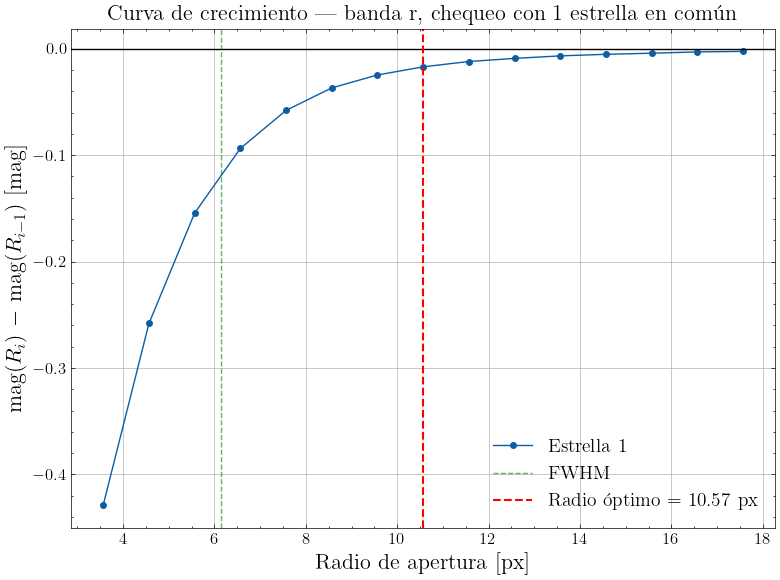

Radio óptimo (Curva de crecimiento — banda r, chequeo con 1 estrella en común): 10.57 px
Sesgo interpolado: -0.015379 mag


In [24]:
estrella_comun_g = [estrellas_candidatas[0]]
estrella_comun_r = convertir_coords_wcs(estrella_comun_g, wcs_sg, wcs_sr)

radio_check_sr, magnitudes_check_sr = curva_crecimiento(
    single_r.data, estrella_comun_r, radios_sr, r_in_cielo_sr, r_out_cielo_sr,
    fwhm_values[2], tolerancia,
    titulo="Curva de crecimiento — banda r, chequeo con 1 estrella en común",
    archivo_salida="4b - curva de crecimiento chequeo (r).pdf"
)

mag_real_interp = np.interp(radio_check_sr, radios_sr, magnitudes_check_sr[0])
mag_escalado_interp = np.interp(radio_optimo_sr, radios_sr, magnitudes_check_sr[0])
diff_mag_bias = mag_real_interp - mag_escalado_interp
print(f"Sesgo interpolado: {diff_mag_bias:.6f} mag")

# Diagrama color-magnitud (g - r) — single-visit y coadd

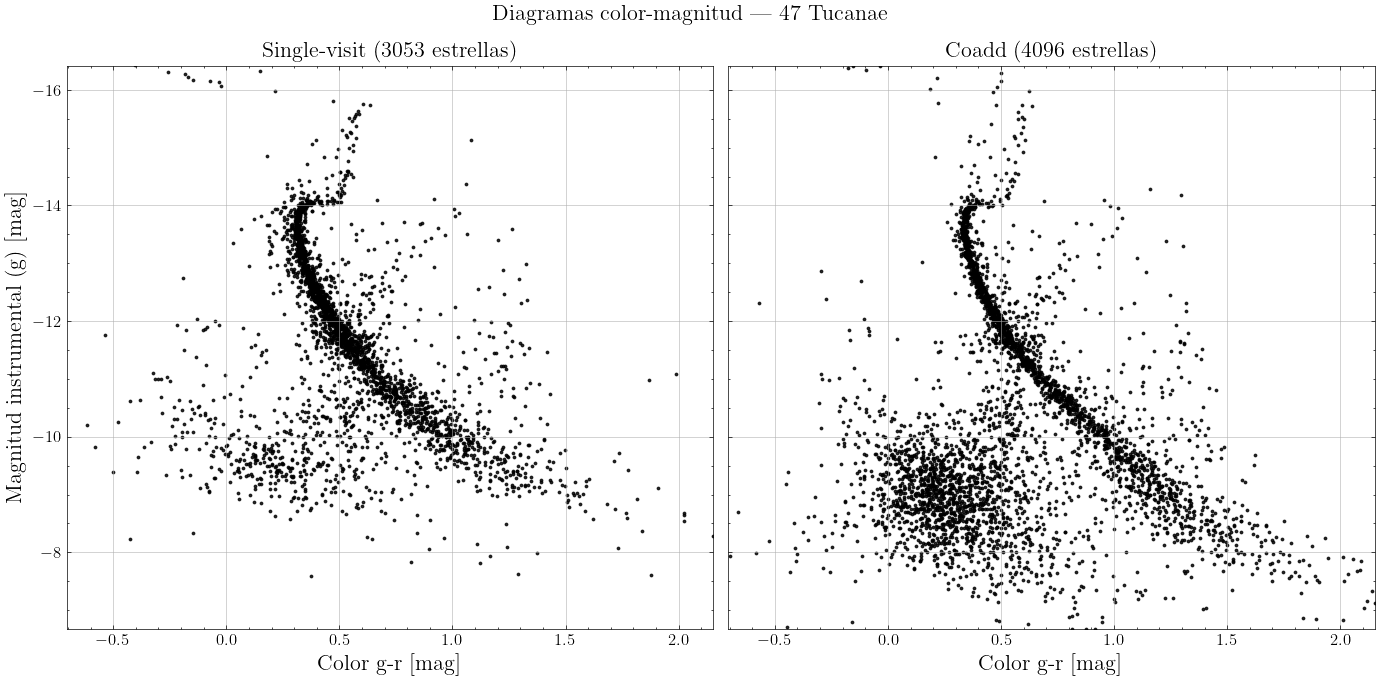

In [25]:
color_sg = magnitud_sg - magnitud_sr
mask_valida_s = np.isfinite(color_sg) & np.isfinite(magnitud_sg)

color_cg = magnitud_cg - magnitud_cr
mask_valida_c = np.isfinite(color_cg) & np.isfinite(magnitud_cg)

# límites compartidos, recortando el 0.5% más extremo para que outliers de fotometría no dominen la escala
color_all = np.concatenate([color_sg[mask_valida_s], color_cg[mask_valida_c]])
mag_all = np.concatenate([magnitud_sg[mask_valida_s], magnitud_cg[mask_valida_c]])
xlim = np.nanpercentile(color_all, [0.5, 99.5])
ylim = np.nanpercentile(mag_all, [0.5, 99.5])

fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharex=True, sharey=True)

axes[0].scatter(color_sg[mask_valida_s], magnitud_sg[mask_valida_s], s=3, alpha=0.8, color='black')
axes[0].set_title(f"Single-visit ({np.sum(mask_valida_s)} estrellas)", fontsize=16)

axes[1].scatter(color_cg[mask_valida_c], magnitud_cg[mask_valida_c], s=3, alpha=0.8, color="black")
axes[1].set_title(f"Coadd ({np.sum(mask_valida_c)} estrellas)", fontsize=16)

for ax in axes:
    ax.set_xlabel("Color g-r [mag]", fontsize=16)
    ax.set_xlim(xlim)
    ax.grid(alpha=0.8)
    ax.tick_params(axis='both', labelsize=12)

axes[0].set_ylabel("Magnitud instrumental (g) [mag]", fontsize=16)
axes[0].set_ylim(ylim[::-1])

fig.suptitle("Diagramas color-magnitud — 47 Tucanae", fontsize=16)
plt.tight_layout()
plt.savefig("7 - diagramas color-magnitud.pdf")
plt.show()

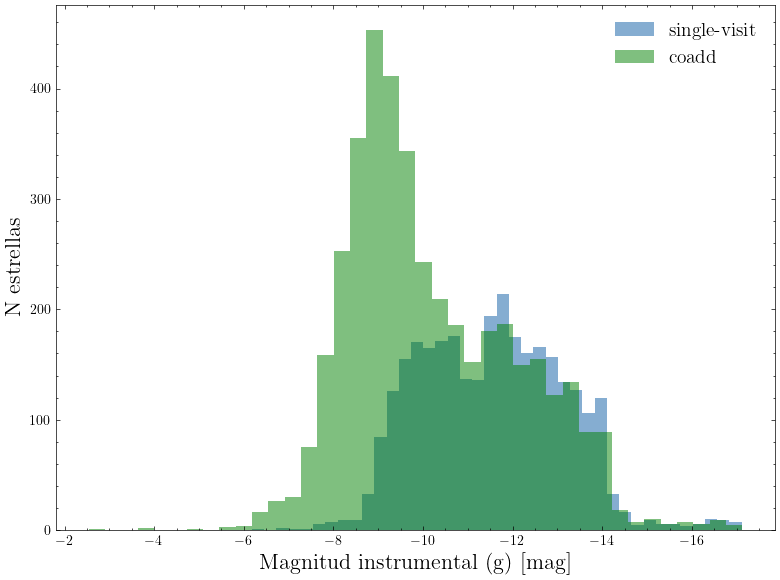

In [26]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(magnitud_sg[mask_valida_s], bins=40, alpha=0.5, label="single-visit")
ax.hist(magnitud_cg[mask_valida_c], bins=40, alpha=0.5, label="coadd", color="green")
ax.set_xlabel("Magnitud instrumental (g) [mag]", fontsize=16)
ax.set_ylabel("N estrellas", fontsize=16)
ax.legend(fontsize=14)
ax.invert_xaxis()
plt.tight_layout()
plt.savefig("8 - histograma magnitudes sg vs cg.pdf")
plt.show()